# GHZ Ground State Eigenvector Workflow

This notebook mirrors the eigenvector workflow, but uses a Hamiltonian whose ground state has two dominant computational-basis components. The reference state is stored as a `KetSum`, so measurements use the two-component GHZ state rather than a single `Ket`.

**Updated:** the Pauli-propagation section now runs `MeanFieldTruncation(k_max, psi_ref)` directly with `psi_ref::KetSum`, alongside coefficient and weight truncation.

In [1]:
using Pkg
Pkg.activate("../")
Pkg.instantiate()

  Activating project at `~/Documents/PauliPropagation/mean_field/PauliOperators.jl`


In [2]:
using PauliOperators
using Plots
using LinearAlgebra
using Plots.PlotMeasures

## Model

Use a ferromagnetic Ising chain plus a global bit-flip term:

```math
H = -J \sum_{i=1}^{N-1} Z_i Z_{i+1} - g X_1 X_2 \cdots X_N.
```

The `ZZ` part makes `|000...0>` and `|111...1>` the lowest classical states. The global `X` string couples only those two aligned states, so for `g > 0` the ground state is the GHZ-plus state.

In [3]:
function ghz_hamiltonian(N::Int; J::Real=1.0, g::Real=0.2)
    H = PauliSum(N, ComplexF64)

    for i in 1:(N - 1)
        H[PauliBasis(Pauli(N; Z=[i, i + 1]))] = -J + 0im
    end

    H[PauliBasis(Pauli(N; X=collect(1:N)))] = -g + 0im
    return H
end

function ghz_reference_ketsum(N::Int; phase=1.0 + 0im)
    psi = KetSum(N, T=ComplexF64)
    psi[Ket(N, 0)] = inv(sqrt(2)) + 0im
    psi[Ket(N, Int128(2)^N - 1)] = phase * inv(sqrt(2))
    return psi
end

function dense_vector(psi::KetSum{N}) where {N}
    return ComplexF64.(Vector(psi))
end

function ket_label(idx::Integer)
    return "|$(idx - 1)>"
end

ket_label (generic function with 1 method)

## Helper Functions

The exact curve uses dense eigendecomposition. The Pauli-propagation curve evolves `O_i(t)` in the Heisenberg picture, then measures `<psi_ref| O_i(t) O_j |psi_ref>` with `psi_ref::KetSum`.

In [4]:
function exact_two_point_curve(H::PauliSum{N}, Oi::PauliSum{N}, Oj::PauliSum{N},
                               psi::KetSum{N}, times::AbstractVector) where {N}
    Hm = Hermitian(Matrix(H))
    Oim = Matrix(Oi)
    Ojm = Matrix(Oj)

    psi_v = dense_vector(psi)
    phi_v = Ojm * psi_v

    F = eigen(Hm)
    lambda, V = F.values, F.vectors

    c_psi = V' * psi_v
    c_phi = V' * phi_v

    ev = zeros(ComplexF64, length(times))
    for (k, t) in enumerate(times)
        psi_t = V * (cis.(-t .* lambda) .* c_psi)
        phi_t = V * (cis.(-t .* lambda) .* c_phi)
        ev[k] = psi_t' * Oim * phi_t
    end

    return ev
end

function get_weight_distribution(ps::PauliSum, N::Int)
    dist = zeros(Float64, N + 1)
    for (p, c) in ps
        dist[weight(p) + 1] += abs2(c)
    end
    return dist
end

function trotter_ev_curve(H::PauliSum{N,T}, Oi::PauliSum{N,T}, Oj::PauliSum{N,T},
                          psi::KetSum{N}, times::AbstractVector, dt::Real,
                          truncation::TruncationStrategy) where {N,T}
    generators, angles = trotterize(H, dt; n_trotter=1, order=2)
    Ot = deepcopy(Oi)

    ev = zeros(ComplexF64, length(times))
    n_terms = zeros(Int, length(times))
    W_mat = zeros(Float64, length(times), N + 1)

    ev[1] = expectation_value(Ot * Oj, psi)
    n_terms[1] = length(Ot)
    W_mat[1, :] = get_weight_distribution(Ot, N)

    for step in 2:length(times)
        Ot = evolve(Ot, generators, angles; truncation=truncation)
        ev[step] = expectation_value(Ot * Oj, psi)
        n_terms[step] = length(Ot)
        W_mat[step, :] = get_weight_distribution(Ot, N)
    end

    return ev, n_terms, W_mat
end

trotter_ev_curve (generic function with 1 method)

## Eigenvector Heatmap

This cell prints eigenvectors whose top two computational-basis components carry essentially all the probability mass.

Eigenvectors with two dominant basis components: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212

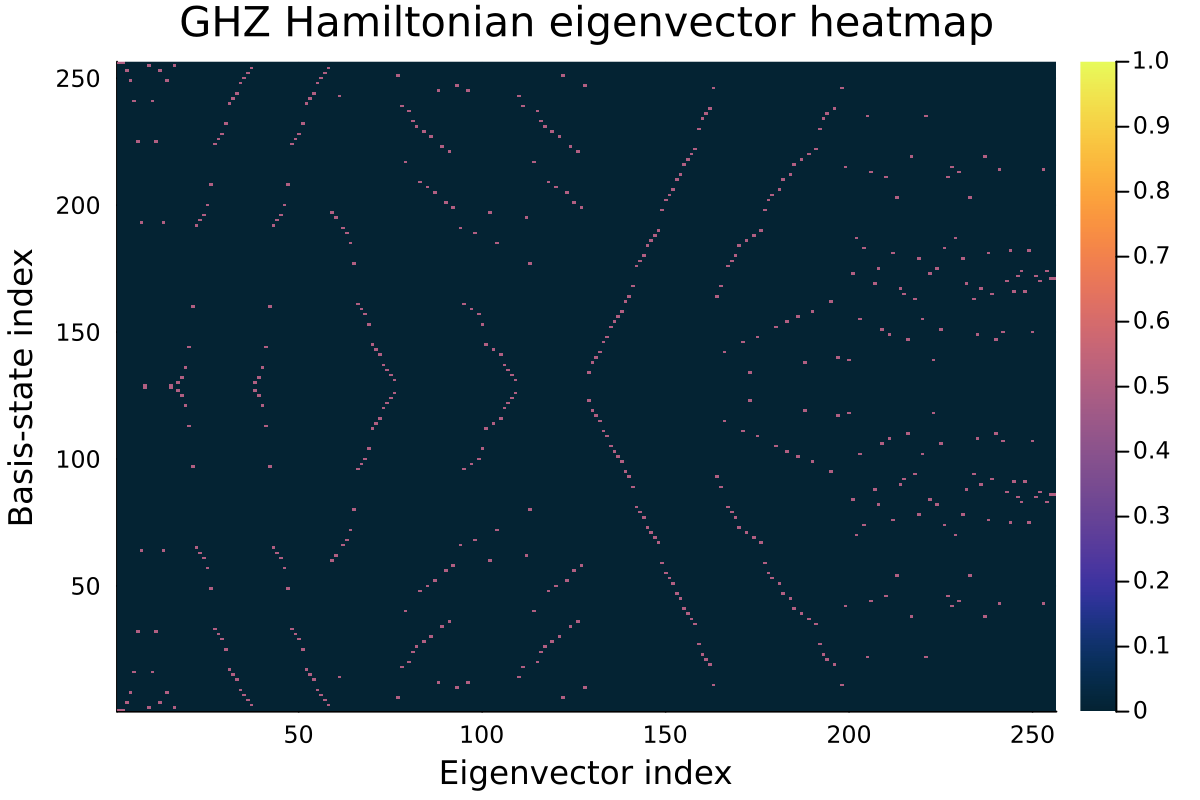

In [5]:
N = 8
J = 1.0
g = 0.2

H = ghz_hamiltonian(N; J=J, g=g)
Hm = Hermitian(Matrix(H))
vals, vecs = eigen(Hm)
heat = abs.(vecs) .^ 2

p_heat = heatmap(
    1:size(heat, 2),
    1:size(heat, 1),
    heat;
    xlabel="Eigenvector index",
    ylabel="Basis-state index",
    title="GHZ Hamiltonian eigenvector heatmap",
    color=:thermal,
    clims=(0, 1),
    dpi=200,
)

dominance = 0.99
min_second_weight = 1e-8
keep = Int[]

for col in 1:size(vecs, 2)
    probs = abs2.(vecs[:, col])
    top2 = partialsortperm(probs, 1:2, rev=true)
    if sum(probs[top2]) > dominance && probs[top2[2]] > min_second_weight
        push!(keep, col)
    end
end

println("Eigenvectors with two dominant basis components: $(keep)")
for col in keep
    probs = abs2.(vecs[:, col])
    top2 = partialsortperm(probs, 1:2, rev=true)
    println("Eigenvector $col  (lambda = $(round(vals[col]; digits=8)))")
    println("  total top-2 weight = $(round(sum(probs[top2]); digits=8))")
    for idx in top2
        println("  $(ket_label(idx)) : amplitude=$(round(vecs[idx, col]; digits=4)), weight=$(round(probs[idx]; digits=4))")
    end
    println()
end

display(p_heat)

## Build The Two-Basis Reference State

The GHZ-plus reference is stored as a `KetSum`:

```math
|psi_ref> = (|000...0> + |111...1>)/sqrt(2).
```

In [6]:
psi_ref = ghz_reference_ketsum(N)
psi_vec = dense_vector(psi_ref)

ground_col = argmin(vals)
ground_overlap = abs2(vecs[:, ground_col]' * psi_vec)

println("Ground-state energy E0 = $(round(vals[ground_col]; digits=8))")
println("Overlap of KetSum GHZ reference with dense ground eigenvector = $(round(ground_overlap; digits=8))")
println("KetSum reference components:")
for (ket, coeff) in sort(collect(psi_ref); by=x -> Int(first(x).v))
    println("  $(ket) : $(round(coeff; digits=6))")
end

println("\nOne-site expectations used by single-site MeanFieldTruncation:")
for q in 1:N
    Xq = PauliSum(Pauli(N; X=[q]))
    Yq = PauliSum(Pauli(N; Y=[q]))
    Zq = PauliSum(Pauli(N; Z=[q]))
    println("  q=$q: <X>=$(round(expectation_value(Xq, psi_ref); digits=6)), <Y>=$(round(expectation_value(Yq, psi_ref); digits=6)), <Z>=$(round(expectation_value(Zq, psi_ref); digits=6))")
end

Ground-state energy E0 = -7.2
Overlap of KetSum GHZ reference with dense ground eigenvector = 1.0
KetSum reference components:
  |00000000> : 0.707107 + 0.0im
  |11111111> : 0.707107 + 0.0im

One-site expectations used by single-site MeanFieldTruncation:
  q=1: <X>=0.0 + 0.0im, <Y>=0.0 + 0.0im, <Z>=0.0 + 0.0im
  q=2: <X>=0.0 + 0.0im, <Y>=0.0 + 0.0im, <Z>=0.0 + 0.0im
  q=3: <X>=0.0 + 0.0im, <Y>=0.0 + 0.0im, <Z>=0.0 + 0.0im
  q=4: <X>=0.0 + 0.0im, <Y>=0.0 + 0.0im, <Z>=0.0 + 0.0im
  q=5: <X>=0.0 + 0.0im, <Y>=0.0 + 0.0im, <Z>=0.0 + 0.0im
  q=6: <X>=0.0 + 0.0im, <Y>=0.0 + 0.0im, <Z>=0.0 + 0.0im
  q=7: <X>=0.0 + 0.0im, <Y>=0.0 + 0.0im, <Z>=0.0 + 0.0im
  q=8: <X>=0.0 + 0.0im, <Y>=0.0 + 0.0im, <Z>=0.0 + 0.0im


## Exact Two-Point Dynamics

Use the same non-equal-time structure as before, now with the GHZ `KetSum`:

```math
C_{ij}(t) = <psi_ref| Z_i(t) Z_j |psi_ref>.
```

For this GHZ Hamiltonian the curve is clean because `Z_j` moves the state between the GHZ-plus and GHZ-minus sectors.

Computing C_45(t) = <psi_ref| Z_4(t) Z_5 |psi_ref>...
C(0) = 1.0 + 0.0im
max |C(t)-C(0)| = 1.99999218


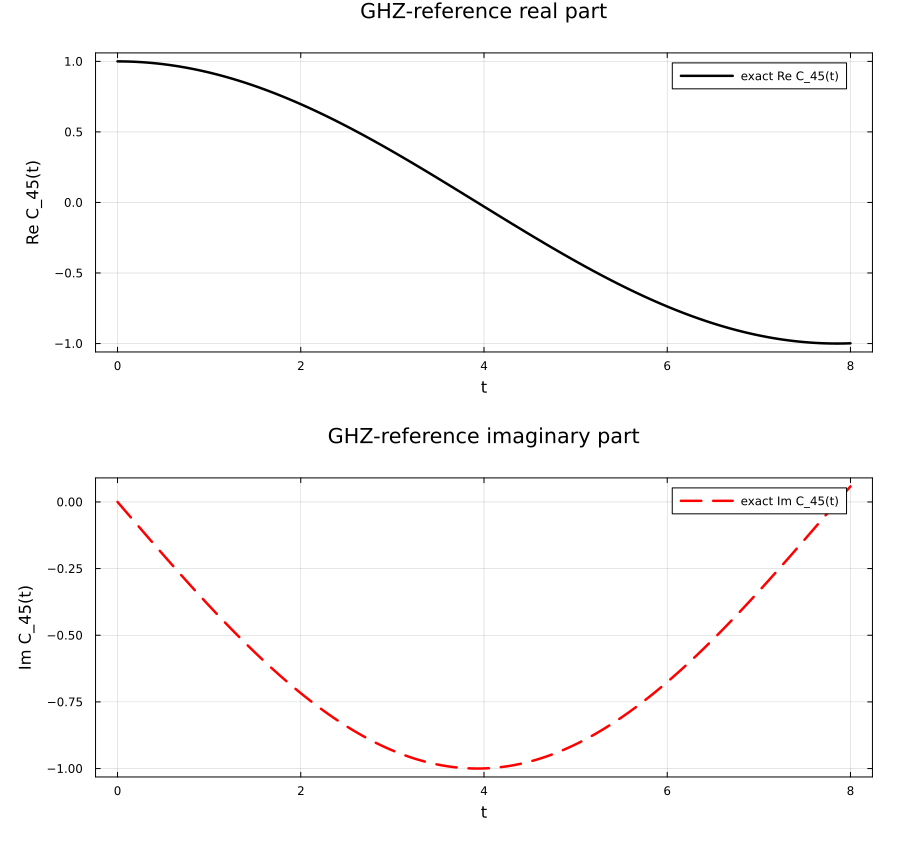

In [7]:
dt = 0.04
T_max = 8.0
times = collect(0.0:dt:T_max)

i = 4
j = 5
Zi = PauliSum(Pauli(N; Z=[i]))
Zj = PauliSum(Pauli(N; Z=[j]))

println("Computing C_$(i)$(j)(t) = <psi_ref| Z_$(i)(t) Z_$(j) |psi_ref>...")
ev_exact = exact_two_point_curve(H, Zi, Zj, psi_ref, times)
println("C(0) = $(round(ev_exact[1]; digits=8))")
println("max |C(t)-C(0)| = $(round(maximum(abs.(ev_exact .- ev_exact[1])); digits=8))")

p_real = plot(times, real.(ev_exact),
    label="exact Re C_$(i)$(j)(t)",
    color=:black, lw=2.5, ls=:solid,
    xlabel="t", ylabel="Re C_$(i)$(j)(t)",
    title="GHZ-reference real part", legend=:topright,
    size=(800, 400), framestyle=:box, margin=5Plots.mm, dpi=100)

p_imag = plot(times, imag.(ev_exact),
    label="exact Im C_$(i)$(j)(t)",
    color=:red, lw=2.5, ls=:dash,
    xlabel="t", ylabel="Im C_$(i)$(j)(t)",
    title="GHZ-reference imaginary part", legend=:topright,
    size=(800, 400), framestyle=:box, margin=5Plots.mm, dpi=100)

plot(p_real, p_imag, layout=(2, 1), size=(900, 850))

## Pauli Propagation: Coeff vs Weight vs KetSum Mean Field

Here the reference state in the measurement is still `psi_ref::KetSum`. The mean-field strategy now also receives the same `KetSum` reference:

```julia
MeanFieldTruncation(k_max, psi_ref)
```

For this GHZ reference, all one-site Pauli expectations vanish, so single-site mean field is expected to behave very similarly to hard weight truncation for high-weight terms. That is a useful diagnostic: it shows what the new `KetSum` support does, and also why GHZ correlations eventually need a cluster/correlated mean-field rule.

In [8]:
thresh = 1e-3
k_max = 4

println("Computing Pauli propagation with CoeffTruncation($(thresh))...")
@time ev_coeff, nt_coeff, W_coeff = trotter_ev_curve(H, Zi, Zj, psi_ref, times, dt,
    CoeffTruncation(thresh))

println("Computing Pauli propagation with WeightTruncation($(k_max)) + CoeffTruncation($(thresh))...")
@time ev_weight, nt_weight, W_weight = trotter_ev_curve(H, Zi, Zj, psi_ref, times, dt,
    CompositeTruncation(WeightTruncation(k_max), CoeffTruncation(thresh)))

println("Computing Pauli propagation with MeanFieldTruncation($(k_max), psi_ref::KetSum) + CoeffTruncation($(thresh))...")
@time ev_mf, nt_mf, W_mf = trotter_ev_curve(H, Zi, Zj, psi_ref, times, dt,
    CompositeTruncation(MeanFieldTruncation(k_max, psi_ref), CoeffTruncation(thresh)))

err_coeff = maximum(abs.(ev_coeff .- ev_exact))
err_weight = maximum(abs.(ev_weight .- ev_exact))
err_mf = maximum(abs.(ev_mf .- ev_exact))
println("max |Coeff - exact| = $(round(err_coeff; digits=8))")
println("max |Weight - exact| = $(round(err_weight; digits=8))")
println("max |MeanField - exact| = $(round(err_mf; digits=8))")

Computing Pauli propagation with CoeffTruncation(0.001)...
  0.156736 seconds (496.41 k allocations: 24.763 MiB, 99.67% compilation time)
Computing Pauli propagation with WeightTruncation(4) + CoeffTruncation(0.001)...
  0.041774 seconds (162.71 k allocations: 8.595 MiB, 98.62% compilation time)
Computing Pauli propagation with MeanFieldTruncation(4, psi_ref::KetSum) + CoeffTruncation(0.001)...
  0.116559 seconds (303.19 k allocations: 16.938 MiB, 10.24% gc time, 88.04% compilation time)
max |Coeff - exact| = 0.0
max |Weight - exact| = 1.98752645
max |MeanField - exact| = 1.98752645


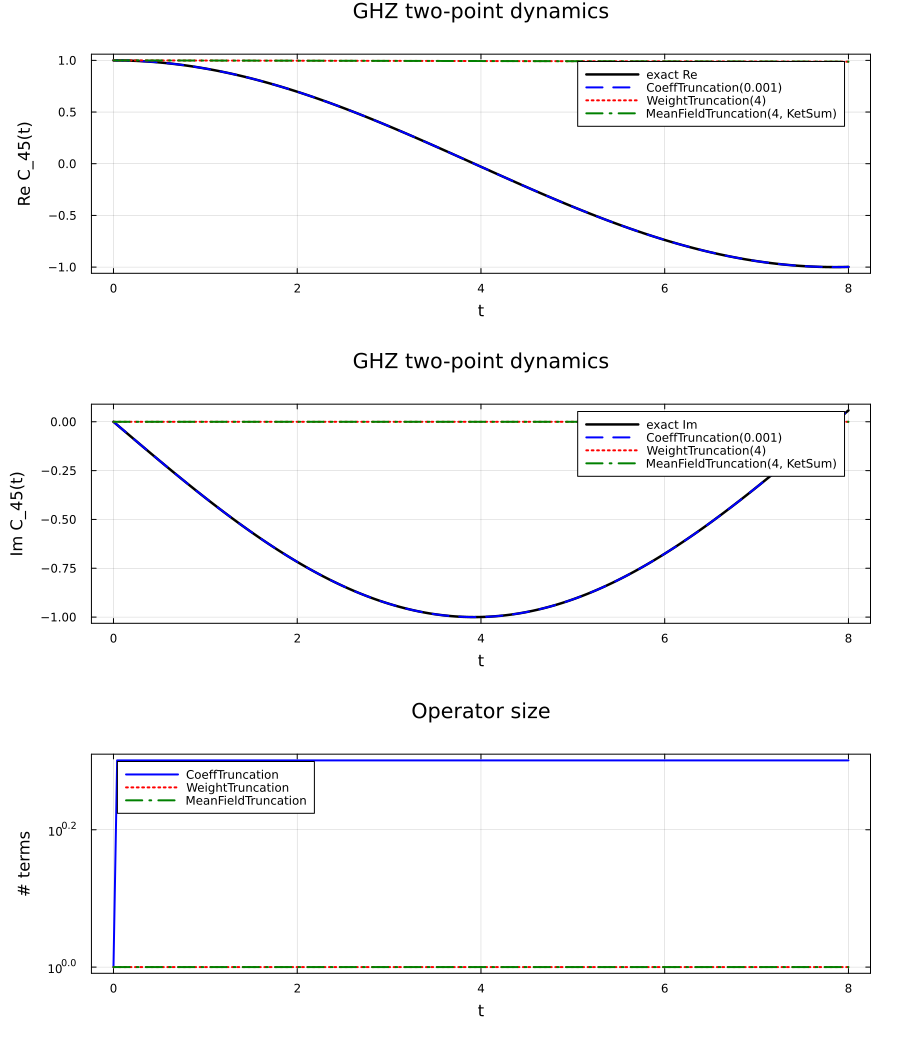

In [9]:
p_corr_re = plot(times, real.(ev_exact),
    label="exact Re", color=:black, lw=2.5,
    xlabel="t", ylabel="Re C_$(i)$(j)(t)",
    title="GHZ two-point dynamics", legend=:topright,
    size=(850, 450), framestyle=:box, margin=5Plots.mm, dpi=100)
plot!(p_corr_re, times, real.(ev_coeff),
    label="CoeffTruncation($(thresh))", color=:blue, lw=2, ls=:dash)
plot!(p_corr_re, times, real.(ev_weight),
    label="WeightTruncation($(k_max))", color=:red, lw=2, ls=:dot)
plot!(p_corr_re, times, real.(ev_mf),
    label="MeanFieldTruncation($(k_max), KetSum)", color=:green, lw=2, ls=:dashdot)

p_corr_im = plot(times, imag.(ev_exact),
    label="exact Im", color=:black, lw=2.5,
    xlabel="t", ylabel="Im C_$(i)$(j)(t)",
    title="GHZ two-point dynamics", legend=:topright,
    size=(850, 450), framestyle=:box, margin=5Plots.mm, dpi=100)
plot!(p_corr_im, times, imag.(ev_coeff),
    label="CoeffTruncation($(thresh))", color=:blue, lw=2, ls=:dash)
plot!(p_corr_im, times, imag.(ev_weight),
    label="WeightTruncation($(k_max))", color=:red, lw=2, ls=:dot)
plot!(p_corr_im, times, imag.(ev_mf),
    label="MeanFieldTruncation($(k_max), KetSum)", color=:green, lw=2, ls=:dashdot)

p_terms = plot(times, nt_coeff,
    label="CoeffTruncation", color=:blue, lw=2,
    xlabel="t", ylabel="# terms", yscale=:log10,
    title="Operator size", legend=:topleft,
    size=(850, 300), framestyle=:box, margin=5Plots.mm, dpi=100)
plot!(p_terms, times, nt_weight,
    label="WeightTruncation", color=:red, lw=2, ls=:dot)
plot!(p_terms, times, nt_mf,
    label="MeanFieldTruncation", color=:green, lw=2, ls=:dashdot)

plot(p_corr_re, p_corr_im, p_terms, layout=(3, 1), size=(900, 1050))

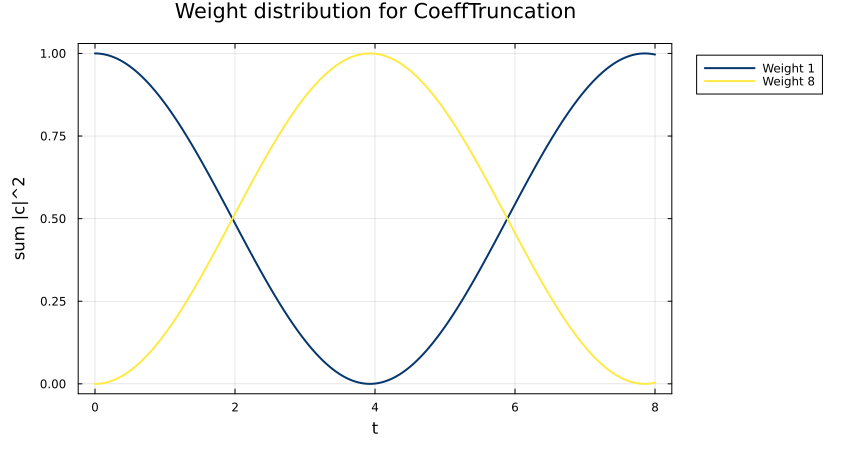

In [10]:
p_dist = plot(xlabel="t",
    ylabel="sum |c|^2",
    title="Weight distribution for CoeffTruncation",
    legend=:outertopright,
    size=(850, 450), framestyle=:box, margin=5Plots.mm, dpi=100)

colors = cgrad(:cividis, N + 1, categorical=true)
for w in 0:N
    if maximum(W_coeff[:, w + 1]) > 1e-12
        plot!(p_dist, times, W_coeff[:, w + 1],
            label="Weight $w", linewidth=2, color=colors[w + 1])
    end
end

p_dist

## Note On Single-Site Mean-Field Truncation

The package now accepts `MeanFieldTruncation(max_weight, reference::KetSum{N})`, and the cells above use the two-component GHZ reference directly.

This is still **single-site** mean field. It uses local expectations like `<X_i>`, `<Y_i>`, and `<Z_i>`. In the equal GHZ state those one-site expectations vanish, even though two-site and global correlations such as `<Z_i Z_j>` and `<X_1 X_2 ... X_N>` can be nonzero. That is why the mean-field curve can look close to `WeightTruncation`: when a high-weight string is reduced by dropping sites with zero local mean, the lower-weight mean-field pieces vanish.

To preserve GHZ correlations at low weight, the next algorithmic step would be a cluster/correlated mean-field rule that uses expectations of blocks, for example `<Z_i Z_j>` or `<X_1 X_2 ... X_N>`, rather than only one-site expectations.